# Oscar — which columns predict default?

26 Sep 2026. Rough working on the Taiwan data: which of the 23 columns carry the
most information about `default payment next month`, and do the strong ones
just repeat each other?

Step 1 (this notebook so far) looks at the columns **one at a time**, then
checks how much they overlap. A later step could fit a model and ask which
columns matter *once the others are known* (permutation importance), which
overlaps with `report/03-MachineLearning`, so agree that with Alex and Louis first.

*Written before `05-cleaning`, so this uses the raw `.xls` (with `PAY_0`). Later work (`06` onwards) uses the cleaned data.*

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif

ROOT = Path.cwd().parent
RAW = ROOT / "data" / "raw"

taiwan = pd.read_excel(RAW / "taiwan-credit-default" / "default of credit card clients.xls",
                       header=1, index_col="ID")
Y = "default payment next month"
X = taiwan.drop(columns=Y)    # the 23 candidate predictors
y = taiwan[Y]                 # the 0/1 label
X.shape

(30000, 23)

## Step 1 — each column on its own: mutual information

**Mutual information (MI)** measures how much knowing a column reduces your
uncertainty about the label. It is 0 if the column tells you nothing about
default, and larger the more it tells you. Unlike correlation, it picks up
any kind of relationship, not only straight-line ones. That matters here:
the default rate by `PAY_0` in `01-working` jumps up rather than rising steadily.

`mutual_info_classif` estimates it differently for two kinds of column, so we
say which is which:

* **discrete** (a small set of codes): `SEX`, `EDUCATION`, `MARRIAGE`, and the
  `PAY_*` repayment statuses. MI is computed from counts.
* **continuous** (amounts and age): estimated from nearest neighbours, which
  involves some randomness, so `random_state=0` makes it repeatable.

MI is in *nats*. The label's own uncertainty is at most ln 2 ≈ 0.69 nats, but
with 22% default it is about 0.53 nats, which gives a sense of scale.
The 35 duplicate rows (`02-duplicates`) are left in; 35 of 30,000 rows makes
no visible difference here.

In [2]:
DISCRETE = ["SEX", "EDUCATION", "MARRIAGE",
            "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

mi = mutual_info_classif(X, y, discrete_features=X.columns.isin(DISCRETE),
                         random_state=0)
mi = pd.Series(mi, index=X.columns).sort_values(ascending=False)

# For scale: the entropy of the label itself, in nats.
p = y.mean()
label_entropy = -(p * np.log(p) + (1 - p) * np.log(1 - p))
print(f"label entropy: {label_entropy:.3f} nats")
mi.round(4)

label entropy: 0.528 nats


PAY_0        0.0761
PAY_2        0.0491
PAY_3        0.0373
PAY_4        0.0329
PAY_5        0.0305
PAY_6        0.0264
PAY_AMT1     0.0248
PAY_AMT3     0.0193
LIMIT_BAL    0.0179
PAY_AMT2     0.0178
PAY_AMT4     0.0175
PAY_AMT5     0.0125
PAY_AMT6     0.0100
BILL_AMT1    0.0100
BILL_AMT3    0.0070
BILL_AMT2    0.0069
BILL_AMT5    0.0065
BILL_AMT6    0.0057
BILL_AMT4    0.0045
EDUCATION    0.0031
SEX          0.0008
MARRIAGE     0.0006
AGE          0.0000
dtype: float64

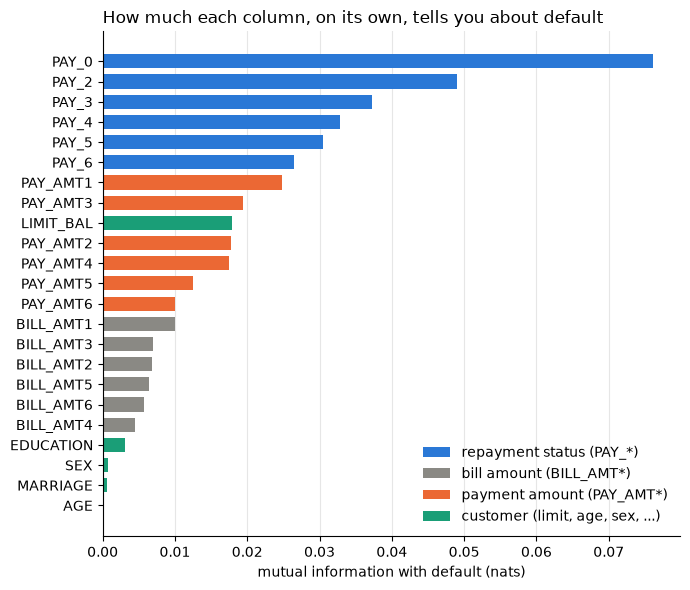

In [3]:
# Horizontal bars, biggest at the top. Bars are coloured by what kind of
# column they are, so you can see whether one kind dominates.
GROUP_COLOURS = {"repayment status (PAY_*)": "#2a78d6",
                 "bill amount (BILL_AMT*)": "#8a8984",
                 "payment amount (PAY_AMT*)": "#eb6834",
                 "customer (limit, age, sex, ...)": "#1a9e77"}

def group(col):
    if col.startswith("PAY_AMT"): return "payment amount (PAY_AMT*)"
    if col.startswith("PAY_"):    return "repayment status (PAY_*)"
    if col.startswith("BILL"):    return "bill amount (BILL_AMT*)"
    return "customer (limit, age, sex, ...)"

order = mi.sort_values()   # barh draws from the bottom up
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(order.index, order.values, height=0.7,
        color=[GROUP_COLOURS[group(c)] for c in order.index])
for name, colour in GROUP_COLOURS.items():          # legend entries
    ax.barh(0, 0, color=colour, label=name)
ax.legend(frameon=False, loc="lower right")
ax.set_xlabel("mutual information with default (nats)")
ax.set_title("How much each column, on its own, tells you about default", loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="0.9"); ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## Step 2 — do the strong columns repeat each other?

If `PAY_0` and `PAY_2` almost always move together, then once a model knows
`PAY_0`, `PAY_2` adds little, even though both score high in step 1. A
**correlation heatmap** shows this: each square is the correlation between two
columns, from -1 (blue) through 0 (white) to +1 (red).

We use **Spearman** correlation, which works on ranks rather than raw values.
The money columns are very skewed (a few huge bills), and ordinary (Pearson)
correlation would be dominated by those few extreme customers.

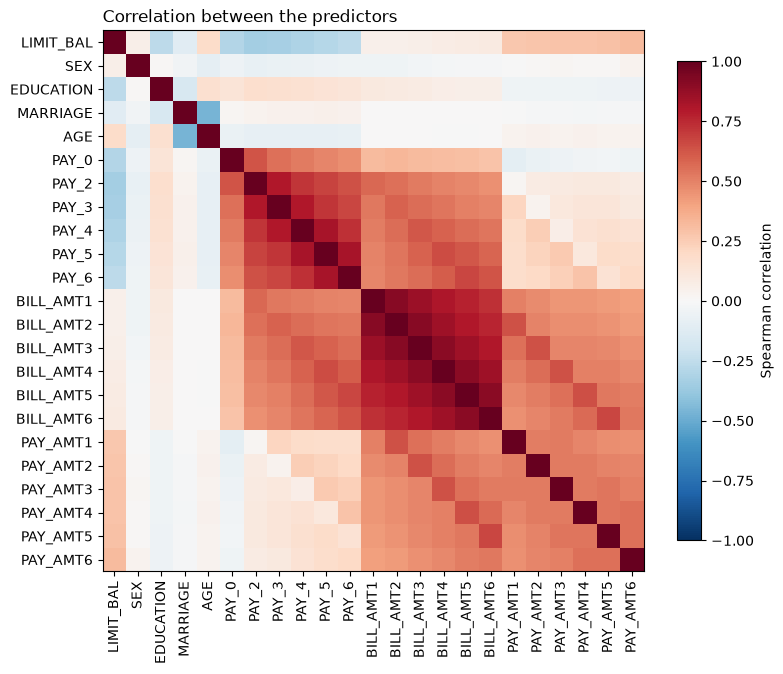

In [4]:
corr = X.corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=90)
ax.set_yticks(range(len(corr)), corr.columns)
fig.colorbar(im, ax=ax, shrink=0.8, label="Spearman correlation")
ax.set_title("Correlation between the predictors", loc="left")
plt.tight_layout()
plt.show()

In [5]:
# The same thing as numbers, for the blocks that look strongest.
pay = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
bill = [f"BILL_AMT{i}" for i in range(1, 7)]
print("PAY_* block:")
print(corr.loc[pay, pay].round(2))
print("\nBILL_AMT* block:")
print(corr.loc[bill, bill].round(2))

PAY_* block:
       PAY_0  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6
PAY_0   1.00   0.63   0.55   0.52   0.49   0.46
PAY_2   0.63   1.00   0.80   0.71   0.67   0.64
PAY_3   0.55   0.80   1.00   0.80   0.72   0.67
PAY_4   0.52   0.71   0.80   1.00   0.82   0.73
PAY_5   0.49   0.67   0.72   0.82   1.00   0.82
PAY_6   0.46   0.64   0.67   0.73   0.82   1.00

BILL_AMT* block:
           BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6
BILL_AMT1       1.00       0.91       0.86       0.81       0.77       0.73
BILL_AMT2       0.91       1.00       0.91       0.85       0.80       0.77
BILL_AMT3       0.86       0.91       1.00       0.90       0.85       0.80
BILL_AMT4       0.81       0.85       0.90       1.00       0.90       0.85
BILL_AMT5       0.77       0.80       0.85       0.90       1.00       0.90
BILL_AMT6       0.73       0.77       0.80       0.85       0.90       1.00


### Notes so far (rough)

* **Repayment status dominates.** All six `PAY_*` columns are the top six, and
  `PAY_0` (the most recent month) is far ahead: 0.076 nats, about 14% of the
  label's 0.53 nats of uncertainty. Each month further back tells you less.
* **Next come payment amounts and the credit limit** (`PAY_AMT*`, `LIMIT_BAL`,
  about 0.01-0.025). Bill amounts are weaker still. **Demographics are close to
  nothing**: `EDUCATION`, `SEX` and `MARRIAGE` are all under 0.004.
* **`AGE` shows 0, but that is an artefact.** The default rate by age is
  U-shaped (27% under 25, 19-20% at 25-35, 27% over 60). Treated as discrete,
  age scores 0.0026, level with `EDUCATION`. The nearest-neighbour estimator
  used for continuous columns rounds small negative estimates up to 0. So age is
  weak, but not zero.
* **The strong columns overlap a lot.** Neighbouring `PAY_*` months correlate
  0.6-0.8, and `BILL_AMT*` months correlate 0.73-0.91. A model will not get six
  times the information from six `PAY_*` columns. Expect `PAY_0` plus one or two
  summaries (e.g. worst status over 6 months, number of late months) to carry
  most of it. Worth testing.
* `LIMIT_BAL` correlates negatively with `PAY_*` (higher limit, fewer late
  payments), so part of its signal is shared with repayment status too.
* **Caveat:** MI is one column at a time. It cannot show columns that matter
  only *in combination*, nor how much a column adds on top of the others. That
  needs a model (permutation importance, or logistic-regression coefficients),
  which is the next step, to be agreed with the owner of `report/03`.